Part 1: Data Audit </b>

In [32]:
import pandas as pd 

# confirm it loads data 
# sep because it's semi-colon separated
df = pd.read_csv('bank-full.csv', sep=';')
print(df.shape)
print(df.columns.tolist())
df.head()


(45211, 17)
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [33]:
# data audit
df.shape
df.info()
df.describe(include='all')
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [34]:
audit_rows = []

# Check for unknown values and create a clean table
for col in df.columns:
    audit_rows.append({
        "column": col,
        "dtype": df[col].dtype,
        "null_count": df[col].isna().sum(),
        "unknown_count": (df[col].astype(str).str.strip().str.lower() == "unknown").sum(),
        "unique_values": df[col].nunique()
    })

audit_df = pd.DataFrame(audit_rows)
display(audit_df)

,column,dtype,null_count,unknown_count,unique_values
0,age,int64,0,0,77
1,job,str,0,288,12
2,marital,str,0,0,3
3,education,str,0,1857,4
4,default,str,0,0,2
5,balance,int64,0,0,7168
6,housing,str,0,0,2
7,loan,str,0,0,2
8,contact,str,0,13020,3
9,day,int64,0,0,31


In [35]:
# Target variable distribution
# Check whether the target variable is balanced or imbalanced.
target_counts = df["y"].value_counts()
target_pct = df["y"].value_counts(normalize=True) * 100

display(target_counts)
display(target_pct.round(2))

y
no     39922
yes     5289
Name: count, dtype: int64

y
no     88.3
yes    11.7
Name: proportion, dtype: float64

<b> Creating tables to understand data </b>

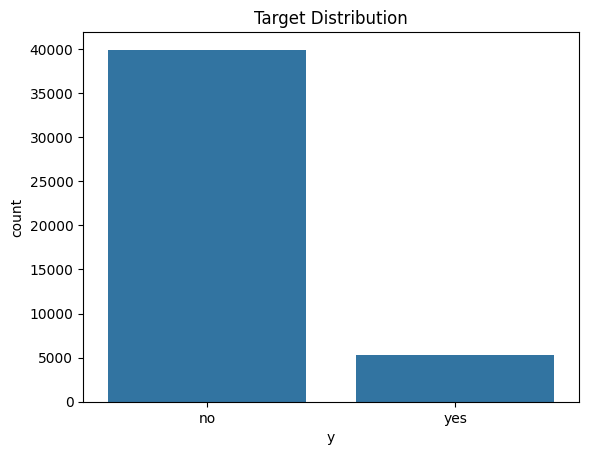

In [36]:
#plot data
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="y")
plt.title("Target Distribution")
plt.show()

In [37]:
# subscription rate by categorical variables
cat_cols = ["contact", "month", "poutcome", "housing", "loan"]

# calculate the subscription rate 
# lambda calculate mean of yes in the y column in cat_cols
def categorical_response_summary(df, col):
    return (
        df.assign(y_bin=(df["y"] == "yes").astype(int))
          .groupby(col)
          .agg(
              total_count=("y_bin", "size"),
              yes_count=("y_bin", "sum"),
              yes_rate=("y_bin", "mean")
          )
          .sort_values("yes_rate", ascending=False)
    )

display(categorical_response_summary(df, "poutcome"))
display(categorical_response_summary(df, "contact"))

,total_count,yes_count,yes_rate
poutcome,,,
success,1511,978,0.647253
other,1840,307,0.166848
failure,4901,618,0.126097
unknown,36959,3386,0.091615


,total_count,yes_count,yes_rate
contact,,,
cellular,29285,4369,0.149189
telephone,2906,390,0.134205
unknown,13020,530,0.040707


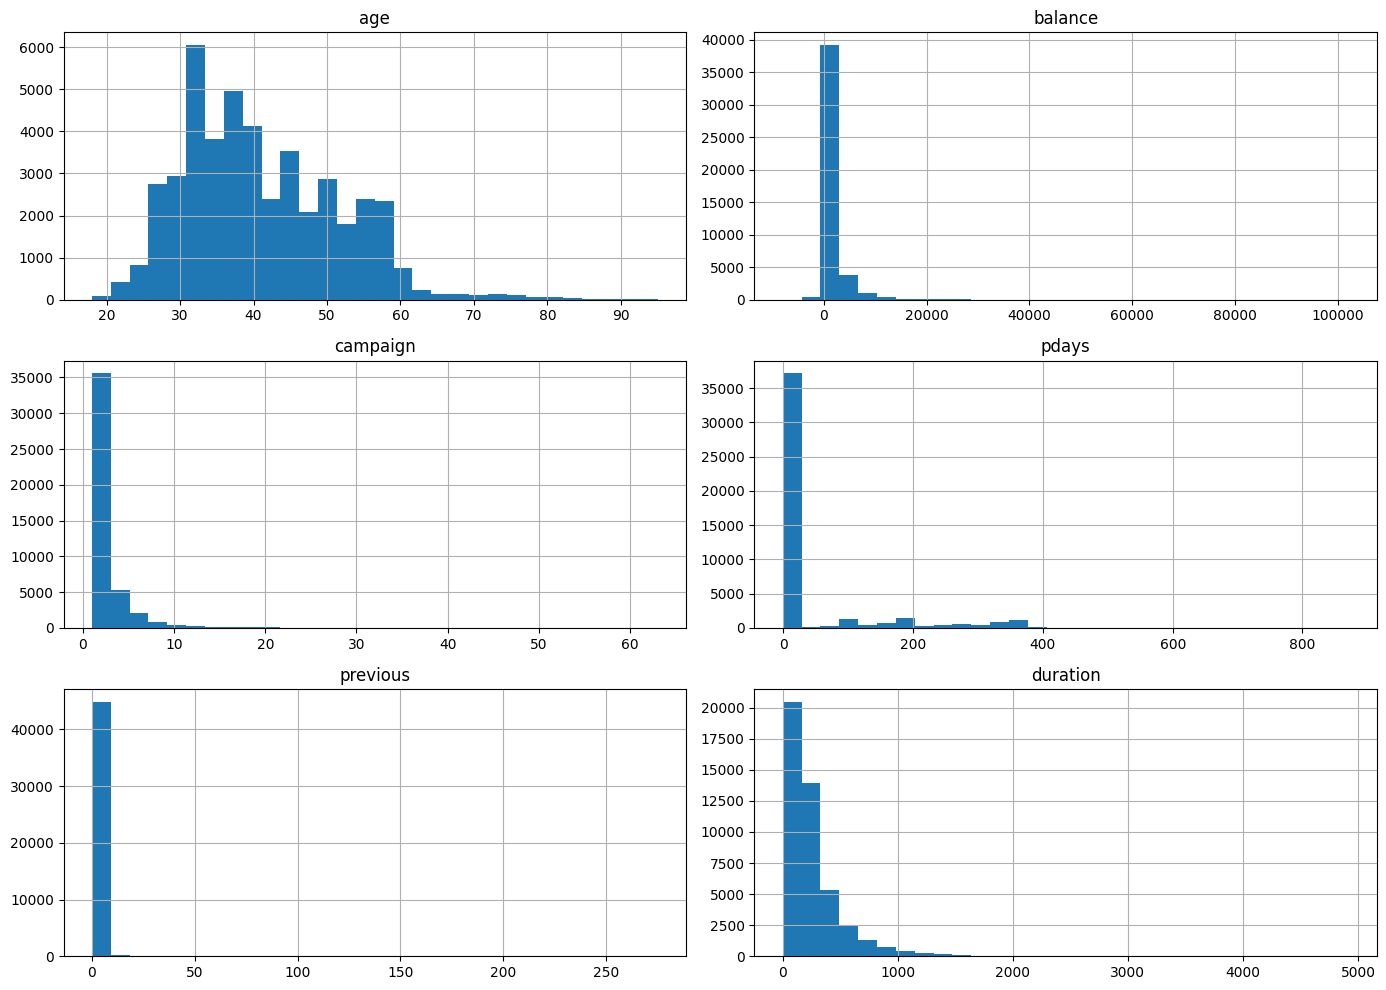

In [38]:
# boxplots of numerical values
num_cols = ["age", "balance", "campaign", "pdays", "previous", "duration"]
df[num_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

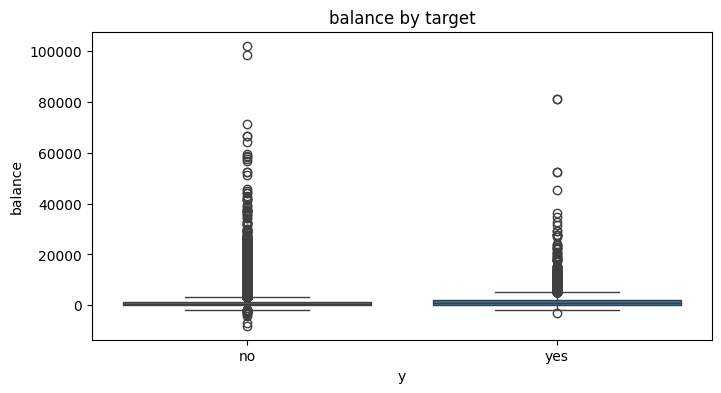

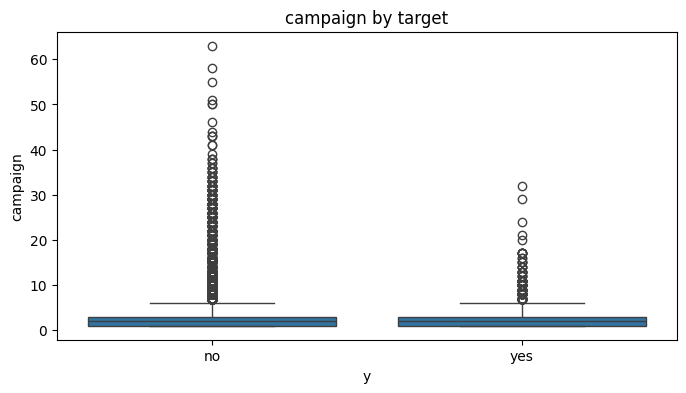

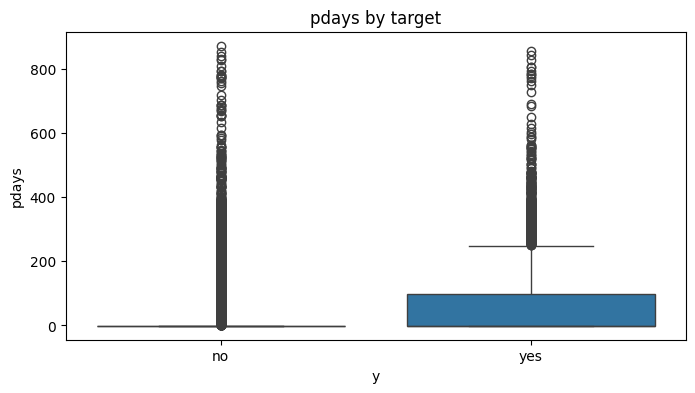

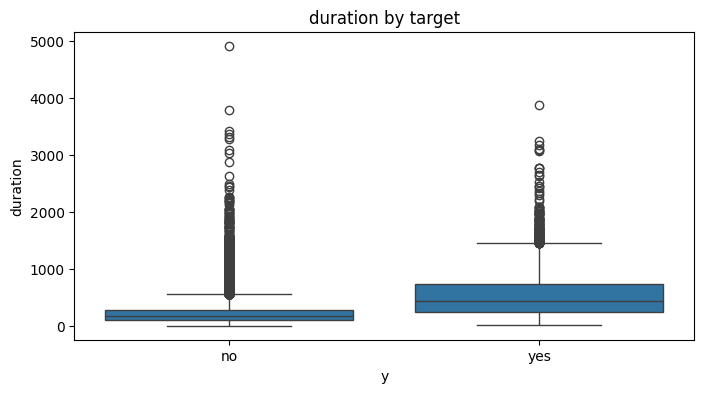

In [39]:
# boxplots of numerical variables by target
for col in ["balance", "campaign", "pdays", "duration"]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x="y", y=col)
    plt.title(f"{col} by target")
    plt.show()

Human Guided


In [50]:
# drop unknowns and recalculate
X = df.drop(columns=["y", "duration"])
y = df["y"].map({"no": 0, "yes": 1})

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.metrics import accuracy_score


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [60]:

# preprocess the data
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

# take numerical cols and standardize them 
# take cat cold and one hot encode them to handle unknowns
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])



/var/folders/87/p5k8cs9s6bz_6qk2rg6t98bc0000gn/T/ipykernel_65903/4235367131.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns.tolist()


In [61]:

# MLP classifier. Max itter to 100 to prevent overfitting
model = Pipeline([
    ("preprocess", preprocessor),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=100,
        early_stopping=True,
        random_state=42
    ))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('mlp', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

In [62]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [63]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8945040362711489
Precision: 0.6494252873563219
Recall: 0.21361058601134217
F1: 0.32147937411095306
ROC-AUC: 0.782817854365404

Confusion Matrix:
 [[7863  122]
 [ 832  226]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94      7985
           1       0.65      0.21      0.32      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.60      0.63      9043
weighted avg       0.87      0.89      0.87      9043



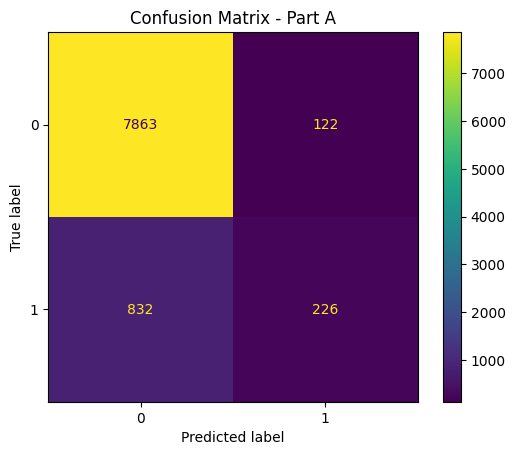

In [64]:
#create a confusion matrix heartmap
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Part A")
plt.show()

In [ ]:
# Compare uncertain vs confidence cases
uncertain_mask = (y_prob >= 0.4) & (y_prob <= 0.6)

print("uncertain cases:", uncertain_mask.sum())
print("proportion uncertain:", uncertain_mask.mean())

Uncertain cases: 279
Proportion uncertain: 0.03085259316598474


In [ ]:
# Then compare uncertain vs confident accuracy:


confident_mask = ~uncertain_mask

print("Accuracy for uncertain cases:",
      accuracy_score(y_test[uncertain_mask], y_pred[uncertain_mask]) if uncertain_mask.sum() > 0 else "No uncertain cases")

print("Accuracy for confident cases:",
      accuracy_score(y_test[confident_mask], y_pred[confident_mask]) if confident_mask.sum() > 0 else "No confident cases")


Accuracy on uncertain cases: 0.5770609318996416
Accuracy on confident cases: 0.9046097672295755
